In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


/tmp/dcs-tmp.u1604520/ipykernel_970091/1428387012.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [10]:
def process(experiment_dir, dgp, contamination):
    results_df = pd.read_csv(experiment_dir/ "results.csv", index_col=["uuid", "replication"])
    results_df = results_df.loc[(results_df["contamination"] == contamination) & (results_df["dgp"] == dgp) & (results_df["num_observations"] == 20)]
    
    gb = results_df.groupby(by=["algorithm", "epsilon", "inference"])
    agg_df = gb.agg({
    "mean_cost": ["mean", "var"],
    "var_cost": ["mean"],
    })
    return agg_df

In [11]:
def plot_df(df, dgp: str, algorithm: str, label: str, axis, marker=False):
    # get a dataframe for each posterior
    df = df.loc[algorithm, :]
    # # mean of variances + variance of means
    bootstrap_var = df["var_cost"]["mean"] + df["mean_cost"]["var"]
   

    # plot mean-variance trade-off
    axis.plot(bootstrap_var, df["mean_cost"]["mean"], marker='o', linestyle="solid", label=label)

    # set title and label epsilon
    axis.set_title(f"DGP is {dgp}")
    axis.legend()
    axis.set_xlabel("out-of-sample variance")
    axis.set_ylabel("out-of-sample mean")
    if marker:
        for i, epsilon in enumerate(df.index.get_level_values("epsilon")):
            if i % 3 == 0:
                axis.text(bootstrap_var[epsilon], df["mean_cost"]["mean"][epsilon], epsilon, ha='left', va='bottom')

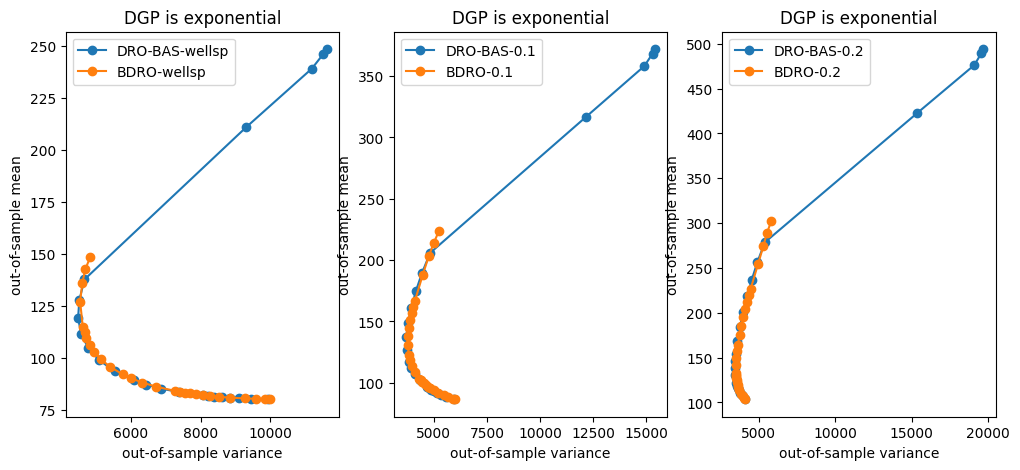

In [12]:
fig, axis = plt.subplots(nrows=1, ncols=3, sharex=False, sharey=False, figsize=(12,5))
experiment_dir = Path("/dcs/large/u1508153/misdro/kl_newsvendor_exp_1d_no_limit")
agg_df = process(experiment_dir, 'contaminated_exp', 0.1)  #n400_mvn_kl_c
plot_df(agg_df, 'exponential', 'kl_dro_bas', 'DRO-BAS-0.1', axis[1])
plot_df(agg_df, 'exponential', 'kl_bdro', 'BDRO-0.1', axis[1])

agg_df = process(experiment_dir, 'contaminated_exp', 0.2)  #cont_multivariate_normal
plot_df(agg_df, 'exponential', 'kl_dro_bas', 'DRO-BAS-0.2', axis[2])
plot_df(agg_df, 'exponential', 'kl_bdro', 'BDRO-0.2', axis[2])

agg_df = process(experiment_dir, 'contaminated_exp', 0.0)
plot_df(agg_df, 'exponential', 'kl_dro_bas', 'DRO-BAS-wellsp', axis[0])
plot_df(agg_df, 'exponential', 'kl_bdro', 'BDRO-wellsp', axis[0])